# Bloch3D — Bands in a simple-cubic cosine potential

> **Artifact boundary.** This is notebook-local exploratory teaching material.
> It is not a canonical artifact, supported PhysKit API, real-material model,
> or claim of pedagogical validation. Deterministic plots and numerical outputs
> are embedded so students can inspect the lesson before rerunning it.
>

## Question

How can a bounded three-dimensional Bloch calculation preserve the operator structure and avoid dense matrices?

## Learning objectives

- Construct a simple-cubic separable Hamiltonian.
- Check selected full sparse eigenvalues against separable sums.
- Follow energy-ordered bands on a stated simple-cubic path.
- Keep finite-grid and high-symmetry-path limitations explicit.

## Shared conventions

Primary calculations use reduced units with $\\hbar^2/(2m)=1$. The first twelve
notebooks use unit baseline box or orthogonal-cell lengths; the final metric
notebooks explicitly define their non-orthogonal lattice bases. PIAB plotting
grids include both hard-wall endpoints. Periodic finite-difference grids are
endpoint-exclusive. Multidimensional meshes use `indexing="ij"` and C-order
flattening, so the last coordinate varies fastest. Eigensolver vectors use
Euclidean normalization; any sampled wavefunction normalization is separately
labelled as uniform quadrature. All helper functions are transparent
notebook-local teaching code, not a public API.

## Connection to the sequence

This completes the orthogonal Bloch-Hamiltonian sequence before metric tensors generalize lattice geometry.


## Simple-cubic teaching model

$$
H_{\mathbf k}=-(\nabla+i\mathbf k)^2
+V_0\sum_{i=x,y,z}\cos(2\pi x_i/L).
$$

The separable model permits low 3D energies to be assembled from 1D spectra.
A full sparse matrix is still checked at one representative $\mathbf k$ point.


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
from scipy import sparse
from scipy.linalg import eigvalsh
from scipy.sparse.linalg import eigsh


def bloch_kinetic_1d(n, length, k):
    h = length / n
    rows = np.repeat(np.arange(n), 3)
    columns = np.column_stack(((np.arange(n) - 1) % n,
                               np.arange(n),
                               (np.arange(n) + 1) % n)).ravel()
    values = np.column_stack((np.full(n, -np.exp(-1j * k * h) / h**2),
                              np.full(n, 2.0 / h**2),
                              np.full(n, -np.exp(1j * k * h) / h**2))).ravel()
    return sparse.coo_matrix((values, (rows, columns)), shape=(n, n)).tocsr()


def cosine_hamiltonian_1d(n, length, k, amplitude=1.0):
    x = np.arange(n) * length / n
    potential = amplitude * np.cos(2 * np.pi * x / length)
    return bloch_kinetic_1d(n, length, k) + sparse.diags(potential, format="csr"), x, potential


def hermiticity_error(matrix):
    difference = matrix - matrix.getH()
    return 0.0 if difference.nnz == 0 else np.max(np.abs(difference.data))


def low_1d_bands(n, length, q_value, count=6, amplitude=1.0):
    k = 2 * np.pi * q_value / length
    matrix, _, _ = cosine_hamiltonian_1d(n, length, k, amplitude)
    return eigvalsh(matrix.toarray(), subset_by_index=(0, min(count, n) - 1))

def piecewise_path(vertices, points_per_segment):
    points = [np.asarray(vertices[0], dtype=float)]
    ticks = [0]
    for start, stop in zip(vertices[:-1], vertices[1:]):
        segment = np.linspace(start, stop, points_per_segment, endpoint=True)[1:]
        points.extend(segment)
        ticks.append(len(points) - 1)
    return np.asarray(points), np.asarray(ticks)

np.set_printoptions(precision=6, suppress=True)


def show_figure(figure):
    """Render a deterministic PNG in notebook and saved-output frontends."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


In [2]:
N, L, V0 = 9, 1.0, 1.0
q_test = np.array([0.17, -0.11, 0.09])
Hs = [cosine_hamiltonian_1d(N, L, 2 * np.pi * q / L, V0)[0] for q in q_test]
I = sparse.identity(N, format="csr")
H3 = (sparse.kron(sparse.kron(Hs[0], I), I, format="csr")
      + sparse.kron(sparse.kron(I, Hs[1]), I, format="csr")
      + sparse.kron(sparse.kron(I, I), Hs[2], format="csr"))
assert H3.shape == (N**3, N**3)
assert np.issubdtype(H3.dtype, np.complexfloating)
assert hermiticity_error(H3) < 1e-12

one_d = [low_1d_bands(N, L, q, count=N, amplitude=V0) for q in q_test]
reference = np.sort((one_d[0][:, None, None]
                     + one_d[1][None, :, None]
                     + one_d[2][None, None, :]).ravel())
eigenvalues, eigenvectors = eigsh(H3, k=6, which="SA", v0=np.ones(H3.shape[0]))
order = np.argsort(eigenvalues)
numeric, eigenvectors = eigenvalues[order], eigenvectors[:, order]
residuals = np.array([
    np.linalg.norm(H3 @ eigenvectors[:, index] - value * eigenvectors[:, index])
    / max(1.0, abs(value))
    for index, value in enumerate(numeric)
])
assert np.allclose(numeric, reference[:6], rtol=1e-10, atol=1e-12)
assert np.max(residuals) < 1e-8
h = L / N
G = 2 * np.pi * np.fft.fftfreq(N, d=h)
free_1d = [np.sort(4.0 / h**2 * np.sin(np.pi * (G * L / (2 * np.pi) + q) / N) ** 2)
           for q in q_test]
free_reference = np.sort((free_1d[0][:, None, None]
                          + free_1d[1][None, :, None]
                          + free_1d[2][None, None, :]).ravel())
free_numeric_1d = [low_1d_bands(N, L, q, count=N, amplitude=0.0) for q in q_test]
free_numeric = np.sort((free_numeric_1d[0][:, None, None]
                        + free_numeric_1d[1][None, :, None]
                        + free_numeric_1d[2][None, None, :]).ravel())
assert np.allclose(free_numeric[:6], free_reference[:6], rtol=1e-10, atol=1e-12)
print("Hamiltonian shape:", H3.shape, "nnz:", H3.nnz)
print("lowest full/reference eigenvalues:\n", np.column_stack([numeric, reference[:6]]))
print("eigensolver residual bound satisfied:", np.max(residuals) < 1e-8)


Hamiltonian shape: (729, 729) nnz: 5103
lowest full/reference eigenvalues:
 [[ 1.894368  1.894368]
 [27.220894 27.220894]
 [31.714085 31.714085]
 [33.2008   33.2008  ]
 [46.275596 46.275596]
 [47.689146 47.689146]]
eigensolver residual bound satisfied: True


In [3]:
vertices = np.array([
    [0.0, 0.0, 0.0],  # Gamma
    [0.5, 0.0, 0.0],  # X
    [0.5, 0.5, 0.0],  # M
    [0.0, 0.0, 0.0],  # Gamma
    [0.5, 0.5, 0.5],  # R
    [0.5, 0.0, 0.0],  # X
])
labels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$", r"$R$", r"$X$"]
q_path, ticks = piecewise_path(vertices, points_per_segment=21)
assert np.allclose(q_path[ticks], vertices, rtol=1e-10, atol=1e-12)
bands = []
for qx, qy, qz in q_path:
    ex = low_1d_bands(N, L, qx, count=N, amplitude=V0)
    ey = low_1d_bands(N, L, qy, count=N, amplitude=V0)
    ez = low_1d_bands(N, L, qz, count=N, amplitude=V0)
    bands.append(np.sort((ex[:, None, None] + ey[None, :, None] + ez[None, None, :]).ravel())[:6])
bands = np.asarray(bands)
assert np.all(np.isfinite(bands))
assert np.all(np.diff(bands, axis=1) >= -1e-10)
assert np.allclose(bands[ticks[1]], bands[ticks[-1]], rtol=1e-10, atol=1e-12)
print("path points:", len(q_path), "band array shape:", bands.shape)


path points: 101 band array shape: (101, 6)


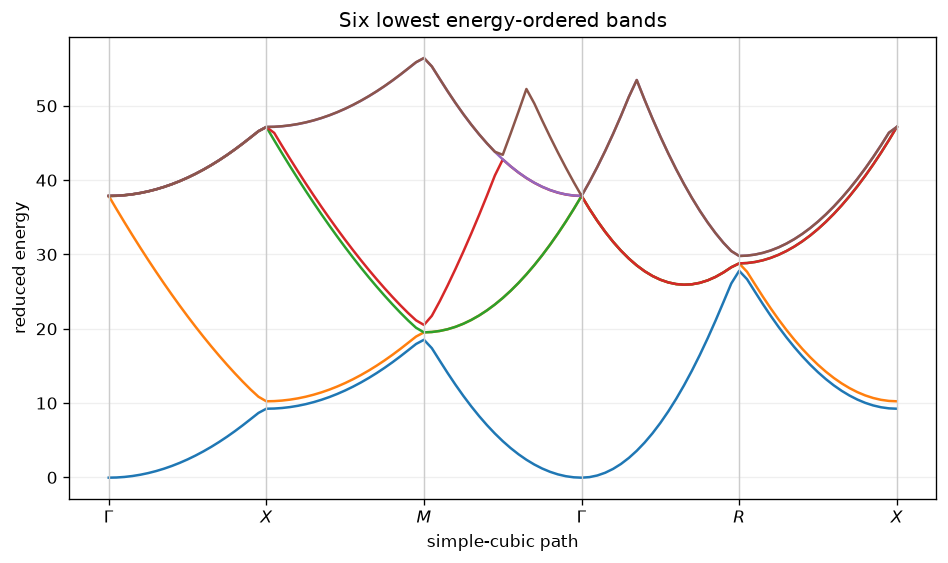

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(np.arange(len(q_path)), bands)
ax.set_xticks(ticks, labels)
ax.set(xlabel="simple-cubic path", ylabel="reduced energy", title="Six lowest energy-ordered bands")
for tick in ticks:
    ax.axvline(tick, color="0.8", linewidth=0.8)
ax.grid(alpha=0.2)
fig.tight_layout()
show_figure(fig)
plt.close(fig)


## Interpretation and limitations

The 9×9×9 representation and selected path are bounded teaching choices, not convergence or global Brillouin-zone evidence. The cosine potential is synthetic and separable.

Successful execution checks only the stated formulas and finite calculations.
It is not, by itself, continuum convergence, physical validation, pedagogical
validation, uncertainty quantification, canonical status, or support.

## Connection forward

MetricTensor1D begins the final geometric generalization; 2D and 3D then relax orthogonality.
